# Bank Marketing Analytics & Subscription Prediction

## 05 — Machine Learning

This notebook documents the end-to-end machine-learning workflow used to prioritize clients before a bank marketing campaign begins.

### Objectives

- Define a strict prediction-time contract.
- Build leakage-safe features.
- preserve the held-out test set until final evaluation.
- Compare baseline and candidate classification models.
- Tune the strongest candidate using training data only.
- Select a classification threshold using out-of-fold probabilities.
- Evaluate the final model once on the untouched test set.
- Translate predictive performance into campaign-oriented business metrics.
- Interpret the model using held-out permutation importance.

> The primary model is a pre-campaign prioritization model. It does not use information generated during or after the current campaign contact.

In [39]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def locate_project_root(start_path: Path) -> Path:
    """Locate the project root from the notebook directory."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        expected_report = (
            candidate
            / "reports"
            / "modeling"
            / "final_test_probability_metrics.csv"
        )

        if expected_report.exists():
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Run the machine-learning scripts before this notebook."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())

MODELING_REPORT_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "modeling"
)

MODEL_DIRECTORY = PROJECT_ROOT / "models"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")
print(f"Modeling reports: {MODELING_REPORT_DIRECTORY}")
print(f"Local model directory: {MODEL_DIRECTORY}")

Project root: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml
Modeling reports: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml\reports\modeling
Local model directory: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml\models


## 1. Load the Modeling Reports

The computational workflow is implemented in reusable Python scripts:

- `src/features.py`
- `src/train.py`
- `src/tune.py`
- `src/select_threshold.py`
- `src/evaluate.py`

This notebook reads the validated outputs created by those scripts.

It does not re-tune the model or select a new threshold using the final test results.

In [40]:
REPORT_PATHS = {
    "feature_contract": (
        MODELING_REPORT_DIRECTORY
        / "feature_contract.csv"
    ),
    "split_summary": (
        MODELING_REPORT_DIRECTORY
        / "train_test_split_summary.csv"
    ),
    "preprocessing_contract": (
        MODELING_REPORT_DIRECTORY
        / "preprocessing_contract.csv"
    ),
    "model_cv_comparison": (
        MODELING_REPORT_DIRECTORY
        / "model_cv_comparison.csv"
    ),
    "model_cv_fold_results": (
        MODELING_REPORT_DIRECTORY
        / "model_cv_fold_results.csv"
    ),
    "tuning_results": (
        MODELING_REPORT_DIRECTORY
        / "random_forest_tuning_results.csv"
    ),
    "best_cv_summary": (
        MODELING_REPORT_DIRECTORY
        / "random_forest_best_cv_summary.csv"
    ),
    "threshold_summary": (
        MODELING_REPORT_DIRECTORY
        / "threshold_selection_summary.csv"
    ),
    "final_probability_metrics": (
        MODELING_REPORT_DIRECTORY
        / "final_test_probability_metrics.csv"
    ),
    "final_threshold_metrics": (
        MODELING_REPORT_DIRECTORY
        / "final_test_threshold_metrics.csv"
    ),
    "confusion_matrices": (
        MODELING_REPORT_DIRECTORY
        / "final_test_confusion_matrices.csv"
    ),
    "classification_report": (
        MODELING_REPORT_DIRECTORY
        / "final_test_classification_report.csv"
    ),
    "roc_curve": (
        MODELING_REPORT_DIRECTORY
        / "final_test_roc_curve.csv"
    ),
    "precision_recall_curve": (
        MODELING_REPORT_DIRECTORY
        / "final_test_precision_recall_curve.csv"
    ),
    "targeting_lift": (
        MODELING_REPORT_DIRECTORY
        / "final_targeting_lift_table.csv"
    ),
    "permutation_importance": (
        MODELING_REPORT_DIRECTORY
        / "test_permutation_importance.csv"
    ),
}

JSON_PATHS = {
    "best_parameters": (
        MODELING_REPORT_DIRECTORY
        / "random_forest_best_parameters.json"
    ),
    "selected_threshold": (
        MODELING_REPORT_DIRECTORY
        / "selected_threshold.json"
    ),
    "model_metadata": (
        MODELING_REPORT_DIRECTORY
        / "final_model_metadata.json"
    ),
}

missing_paths = [
    path
    for path in [
        *REPORT_PATHS.values(),
        *JSON_PATHS.values(),
    ]
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Required modeling outputs are missing:\n"
        + "\n".join(
            f"- {path}"
            for path in missing_paths
        )
    )

print(
    "All required machine-learning reports "
    "were found successfully."
)

All required machine-learning reports were found successfully.


In [41]:
reports = {
    report_name: pd.read_csv(report_path)
    for report_name, report_path
    in REPORT_PATHS.items()
}

json_reports = {
    report_name: json.loads(
        report_path.read_text(
            encoding="utf-8"
        )
    )
    for report_name, report_path
    in JSON_PATHS.items()
}

print(f"CSV reports loaded: {len(reports)}")
print(f"JSON reports loaded: {len(json_reports)}")

print("\nCSV report names:")

for report_name in reports:
    print(f"- {report_name}")

CSV reports loaded: 16
JSON reports loaded: 3

CSV report names:
- feature_contract
- split_summary
- preprocessing_contract
- model_cv_comparison
- model_cv_fold_results
- tuning_results
- best_cv_summary
- threshold_summary
- final_probability_metrics
- final_threshold_metrics
- confusion_matrices
- classification_report
- roc_curve
- precision_recall_curve
- targeting_lift
- permutation_importance


## 2. Prediction Contract

The primary business objective is to prioritize clients **before the current campaign begins**.

At prediction time, the bank may use:

- Customer demographic information.
- Existing account information.
- Existing financial obligations.
- Historical campaign-contact information.
- Previous campaign outcomes.

The model excludes variables generated during the current campaign:

- `contact`
- `day`
- `month`
- `duration`
- `campaign`

In particular, `duration` is known only after a call ends and would create temporal data leakage.

In [42]:
feature_contract = reports[
    "feature_contract"
].copy()

display(feature_contract)

,feature,source_or_derived,primary_model_status,model_representation,reason
0,age,source,included,numeric,Customer attribute available before the campai...
1,job,source,included,categorical,Customer attribute available before the campaign.
2,marital,source,included,categorical,Available before the campaign; requires fairne...
3,education,source,included,categorical,Customer attribute available before the campaign.
4,default,source,included,categorical,Existing financial-status information.
5,balance,source,included,numeric,Existing account information available before ...
6,housing,source,included,categorical,Existing financial-obligation information.
7,loan,source,included,categorical,Existing financial-obligation information.
8,contact,source,excluded,not used,Current-campaign execution information.
9,day,source,excluded,not used,Current-campaign execution date.


In [43]:
feature_status_summary = (
    feature_contract
    .groupby(
        "primary_model_status",
        dropna=False,
    )
    .size()
    .reset_index(name="number_of_features")
    .sort_values(
        "number_of_features",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(feature_status_summary)

,primary_model_status,number_of_features
0,included,13
1,excluded,5
2,transformed,1


In [44]:
excluded_features = (
    feature_contract.loc[
        feature_contract[
            "primary_model_status"
        ] == "excluded",
        [
            "feature",
            "reason",
        ],
    ]
    .reset_index(drop=True)
)

display(excluded_features)

,feature,reason
0,contact,Current-campaign execution information.
1,day,Current-campaign execution date.
2,month,Current-campaign execution timing.
3,duration,Known only after the call ends; temporal data ...
4,campaign,Current-campaign contact count may accumulate ...


### Leakage-Control Decision

The project uses a stricter pre-campaign model rather than a model that relies on information collected during the call.

This may reduce apparent predictive performance, but it produces a model that can be used at the actual client-prioritization decision point.

A model with excellent historical performance but unavailable deployment-time features would not be operationally valid.

## 3. Leakage-Safe Feature Engineering

The source variable `pdays` uses `-1` to indicate that the client was not contacted previously.

The modeling workflow separates that meaning into:

- `previously_contacted`
- `pdays_since_previous_contact`

The second feature contains a missing value only when no previous contact occurred. Missing-value imputation is learned inside each training fold.

A second deterministic feature, `negative_balance`, identifies clients whose account balance is below zero.

In [45]:
preprocessing_contract = reports[
    "preprocessing_contract"
].copy()

display(preprocessing_contract)

,feature_group,features,missing_value_strategy,encoding_or_scaling,notes
0,numerical,"age, balance, previous, pdays_since_previous_c...",Median imputation learned within each training...,StandardScaler learned within each training fold,A missingness indicator is added for pdays_sin...
1,categorical,"job, marital, education, default, housing, loa...",Most-frequent imputation learned within each t...,OneHotEncoder with handle_unknown='ignore',Unseen categories in validation or test data d...


### Preprocessing Pipeline

Numerical features are processed using:

1. Median imputation.
2. Missing-value indicators.
3. Standard scaling.

Categorical features are processed using:

1. Most-frequent imputation.
2. One-hot encoding.
3. Unknown-category handling.

All learned preprocessing parameters are fitted inside the training pipeline rather than on the complete dataset.

## 4. Stratified Train/Test Split

The dataset is divided into:

- 80% training data.
- 20% held-out test data.

The split is stratified using the binary target so that the subscriber proportion remains similar across the full dataset, training set, and test set.

The test set is not used during candidate-model comparison, hyperparameter tuning, or threshold selection.

In [46]:
split_summary = reports[
    "split_summary"
].copy()

display(split_summary)

,split,record_count,non_subscribers,subscribers,subscription_rate_percentage
0,full_dataset,45211,39922,5289,11.6985
1,train,36168,31937,4231,11.6982
2,test,9043,7985,1058,11.6997


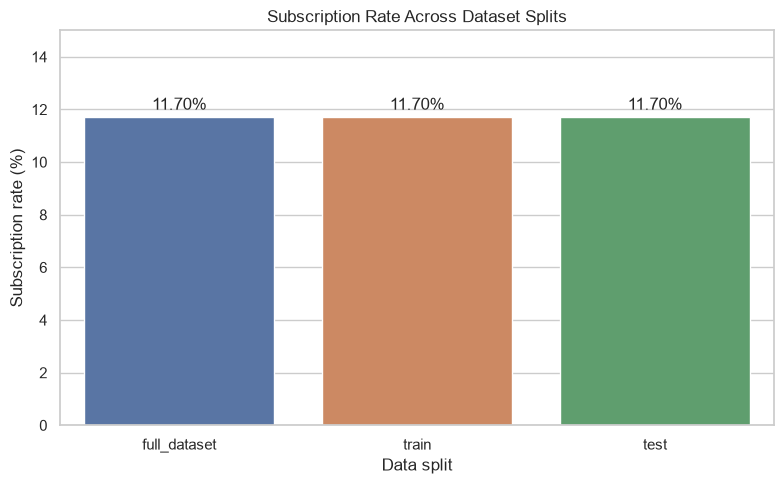

In [47]:
figure, axis = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=split_summary,
    x="split",
    y="subscription_rate_percentage",
    hue="split",
    legend=False,
    ax=axis,
)

axis.set_title(
    "Subscription Rate Across Dataset Splits"
)
axis.set_xlabel("Data split")
axis.set_ylabel("Subscription rate (%)")
axis.set_ylim(0, 15)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
    )

plt.tight_layout()
plt.show()

## 5. Candidate-Model Benchmarking

The following models were evaluated using five-fold stratified cross-validation on the training set:

- Dummy prior classifier.
- Logistic Regression.
- Class-balanced Logistic Regression.
- Class-balanced Random Forest.

Because subscribers represent only approximately 11.7% of the records, Average Precision is used as the primary ranking metric.

ROC-AUC, balanced accuracy, precision, recall, and F1 are also reported.

In [48]:
model_comparison = reports[
    "model_cv_comparison"
].copy()

model_comparison_display = (
    model_comparison[
        [
            "model",
            "mean_roc_auc",
            "std_roc_auc",
            "mean_average_precision",
            "std_average_precision",
            "mean_balanced_accuracy",
            "mean_precision",
            "mean_recall",
            "mean_f1",
            "mean_fit_time_seconds",
        ]
    ]
    .copy()
)

display(model_comparison_display)

,model,mean_roc_auc,std_roc_auc,mean_average_precision,std_average_precision,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_fit_time_seconds
0,random_forest_balanced,0.7343,0.0038,0.3782,0.0159,0.6786,0.2974,0.5200,0.3783,6.4791
1,logistic_regression,0.7133,0.0072,0.3474,0.0093,0.5758,0.6666,0.1624,0.2610,0.3254
2,logistic_regression_balanced,0.7136,0.0069,0.3451,0.0096,0.6616,0.2240,0.5980,0.3258,1.1246
3,dummy_prior,0.5000,0.0000,0.1170,0.0001,0.5000,0.0000,0.0000,0.0000,0.1546


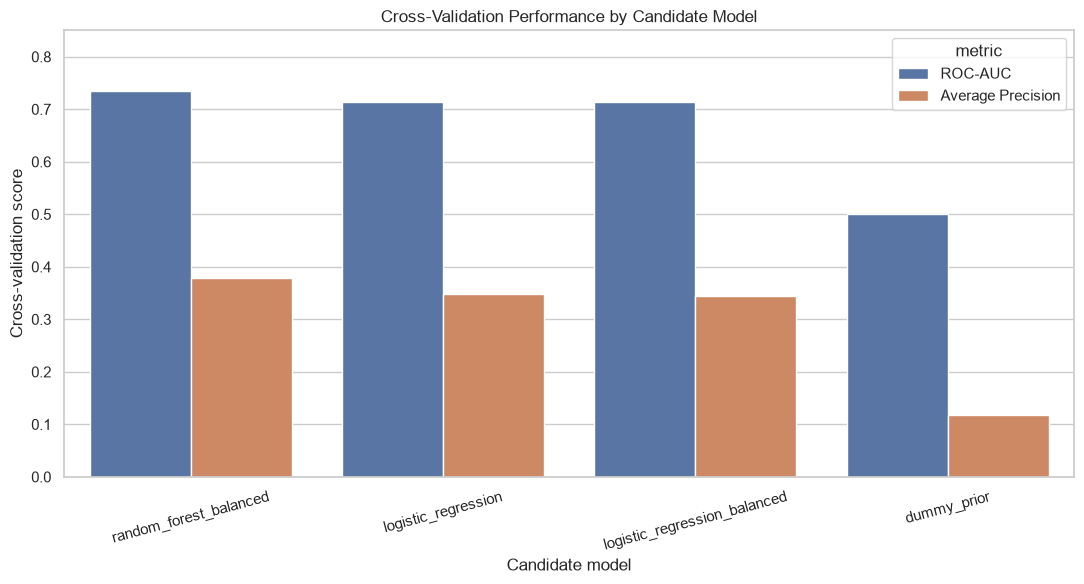

In [49]:
comparison_plot_data = (
    model_comparison[
        [
            "model",
            "mean_roc_auc",
            "mean_average_precision",
        ]
    ]
    .melt(
        id_vars="model",
        var_name="metric",
        value_name="score",
    )
)

comparison_plot_data["metric"] = (
    comparison_plot_data["metric"]
    .map(
        {
            "mean_roc_auc": "ROC-AUC",
            "mean_average_precision": (
                "Average Precision"
            ),
        }
    )
)

figure, axis = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=comparison_plot_data,
    x="model",
    y="score",
    hue="metric",
    ax=axis,
)

axis.set_title(
    "Cross-Validation Performance by Candidate Model"
)
axis.set_xlabel("Candidate model")
axis.set_ylabel("Cross-validation score")
axis.tick_params(axis="x", rotation=15)
axis.set_ylim(0, 0.85)

plt.tight_layout()
plt.show()

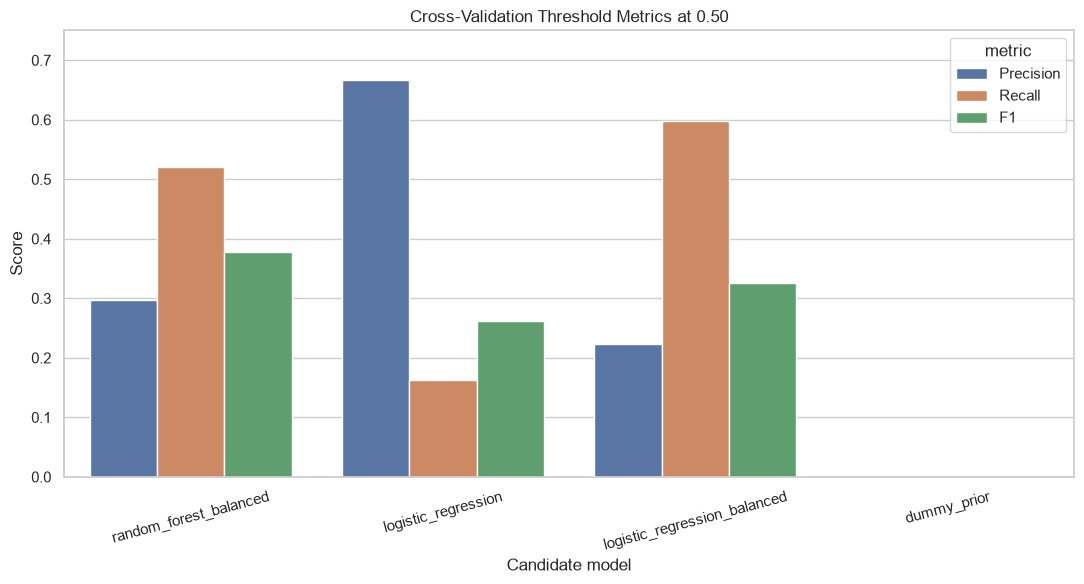

In [50]:
precision_recall_comparison = (
    model_comparison[
        [
            "model",
            "mean_precision",
            "mean_recall",
            "mean_f1",
        ]
    ]
    .melt(
        id_vars="model",
        var_name="metric",
        value_name="score",
    )
)

precision_recall_comparison["metric"] = (
    precision_recall_comparison["metric"]
    .map(
        {
            "mean_precision": "Precision",
            "mean_recall": "Recall",
            "mean_f1": "F1",
        }
    )
)

figure, axis = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=precision_recall_comparison,
    x="model",
    y="score",
    hue="metric",
    ax=axis,
)

axis.set_title(
    "Cross-Validation Threshold Metrics at 0.50"
)
axis.set_xlabel("Candidate model")
axis.set_ylabel("Score")
axis.tick_params(axis="x", rotation=15)
axis.set_ylim(0, 0.75)

plt.tight_layout()
plt.show()

### Candidate-Model Result

The balanced Random Forest produced the strongest cross-validation performance on:

- Average Precision.
- ROC-AUC.
- Balanced accuracy.
- F1-score.

The standard Logistic Regression produced higher precision at the default threshold, but its recall was low.

The class-balanced models increased recall by accepting more false-positive predictions.

## 6. Random Forest Hyperparameter Tuning

The Random Forest was tuned using randomized search and five-fold stratified cross-validation.

The selection metric remained Average Precision.

The test set was not used during hyperparameter selection.

In [51]:
best_parameters = json_reports[
    "best_parameters"
]

display(
    pd.DataFrame(
        {
            "parameter": list(
                best_parameters.keys()
            ),
            "selected_value": [
                str(value)
                for value
                in best_parameters.values()
            ],
        }
    )
)

,parameter,selected_value
0,classifier__class_weight,balanced_subsample
1,classifier__max_depth,10
2,classifier__max_features,0.5
3,classifier__max_samples,None
4,classifier__min_samples_leaf,10
5,classifier__min_samples_split,10
6,classifier__n_estimators,450


In [52]:
best_cv_summary = reports[
    "best_cv_summary"
].copy()

display(best_cv_summary)

,selection_metric,best_average_precision,std_average_precision,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,number_of_candidates,number_of_folds
0,average_precision,0.3806,0.0121,0.7339,0.0016,0.6768,0.2919,0.5216,0.3741,16,5


In [53]:
top_tuning_candidates = (
    reports["tuning_results"]
    .sort_values(
        "rank_test_average_precision"
    )
    .head(5)
    .reset_index(drop=True)
)

display(top_tuning_candidates)

,param_classifier__class_weight,param_classifier__max_depth,param_classifier__max_features,param_classifier__max_samples,param_classifier__min_samples_leaf,param_classifier__min_samples_split,param_classifier__n_estimators,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,std_test_roc_auc,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_fit_time,std_fit_time
0,balanced_subsample,10.0000,0.5,NaN,10,10,450,1,0.3806,0.0121,0.7339,0.0016,0.6768,0.2919,0.5216,0.3741,30.3960,0.4601
1,balanced_subsample,10.0000,0.5,0.8500,10,5,450,2,0.3800,0.0115,0.7340,0.0017,0.6769,0.2936,0.5200,0.3751,34.8728,0.4613
2,balanced,10.0000,sqrt,NaN,10,2,300,3,0.3778,0.0112,0.7360,0.0028,0.6787,0.2757,0.5486,0.3669,8.0684,0.1228
3,balanced_subsample,20.0000,sqrt,NaN,20,5,450,4,0.3776,0.0114,0.7356,0.0012,0.6790,0.2867,0.5339,0.3730,31.9468,0.4159
4,balanced,16.0000,log2,NaN,5,2,300,5,0.3774,0.0120,0.7331,0.0022,0.6798,0.2815,0.5434,0.3708,8.9415,0.1640


### Hyperparameter-Tuning Interpretation

The tuning process searched multiple combinations of:

- Number of trees.
- Tree depth.
- Minimum samples per split.
- Minimum samples per leaf.
- Feature sampling.
- Class weighting.
- Bootstrap sample size.

The best candidate was selected entirely from cross-validation performance on the training data.

## 7. Training-Only Threshold Selection

The default classification threshold of `0.50` is not automatically optimal for an imbalanced campaign-targeting problem.

The tuned Random Forest generated out-of-fold probabilities for every training record.

The selected threshold maximized the out-of-fold F1-score.

The final test set was not used in this decision.

In [54]:
selected_threshold_metadata = (
    json_reports["selected_threshold"]
)

display(
    pd.DataFrame(
        [
            selected_threshold_metadata
        ]
    )
)

,number_of_folds,oof_f1,oof_f2,oof_precision,oof_recall,predicted_positive_percentage,selection_rule,test_set_used,threshold
0,5,0.4071,0.4067,0.4076,0.4065,11.6678,maximize_oof_f1,False,0.5951


In [55]:
threshold_summary = reports[
    "threshold_summary"
].copy()

threshold_display_columns = [
    "threshold_name",
    "threshold",
    "precision",
    "recall",
    "f1",
    "specificity",
    "balanced_accuracy",
    "predicted_positive_percentage",
    "true_positives",
    "false_positives",
    "false_negatives",
    "true_negatives",
    "oof_roc_auc",
    "oof_average_precision",
]

display(
    threshold_summary[
        threshold_display_columns
    ]
)

,threshold_name,threshold,precision,recall,f1,specificity,balanced_accuracy,predicted_positive_percentage,true_positives,false_positives,false_negatives,true_negatives,oof_roc_auc,oof_average_precision
0,selected_max_f1,0.5951,0.4076,0.4065,0.4071,0.9217,0.6641,11.6678,1720,2500,2511,29437,0.7336,0.3791
1,default_0_50,0.5000,0.2913,0.5216,0.3738,0.8319,0.6768,20.9467,2207,5369,2024,26568,0.7336,0.3791


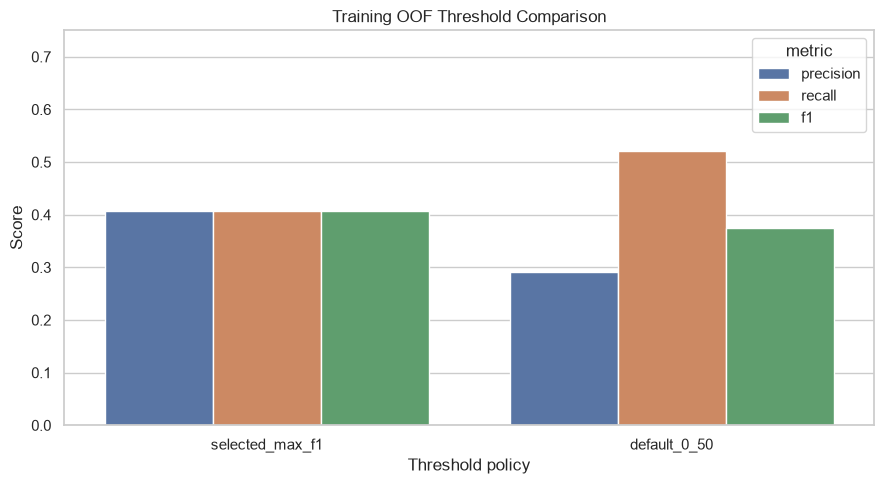

In [56]:
threshold_plot_data = (
    threshold_summary[
        [
            "threshold_name",
            "precision",
            "recall",
            "f1",
        ]
    ]
    .melt(
        id_vars="threshold_name",
        var_name="metric",
        value_name="score",
    )
)

figure, axis = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=threshold_plot_data,
    x="threshold_name",
    y="score",
    hue="metric",
    ax=axis,
)

axis.set_title(
    "Training OOF Threshold Comparison"
)
axis.set_xlabel("Threshold policy")
axis.set_ylabel("Score")
axis.set_ylim(0, 0.75)

plt.tight_layout()
plt.show()

### Threshold-Selection Result

The selected threshold is approximately `0.595`.

Compared with the default threshold, it is more conservative when assigning the subscriber class.

The threshold was selected before the final test set was opened, which prevents test-set performance from influencing the operating policy.

In [57]:
assert len(reports) == len(REPORT_PATHS)
assert len(json_reports) == len(JSON_PATHS)

assert len(split_summary) == 3

assert int(
    split_summary.loc[
        split_summary["split"]
        == "full_dataset",
        "record_count",
    ].iloc[0]
) == 45_211

assert set(
    model_comparison["model"]
) == {
    "dummy_prior",
    "logistic_regression",
    "logistic_regression_balanced",
    "random_forest_balanced",
}

best_candidate = (
    model_comparison
    .sort_values(
        "mean_average_precision",
        ascending=False,
    )
    .iloc[0]
)

assert (
    best_candidate["model"]
    == "random_forest_balanced"
)

assert (
    selected_threshold_metadata[
        "test_set_used"
    ]
    is False
)

assert (
    0
    <= float(
        selected_threshold_metadata[
            "threshold"
        ]
    )
    <= 1
)

assert len(threshold_summary) == 2

print(
    "Machine-learning notebook setup, "
    "model comparison, tuning, and threshold-selection "
    "checks passed successfully."
)

Machine-learning notebook setup, model comparison, tuning, and threshold-selection checks passed successfully.


## 8. Final Held-Out Test Evaluation

The final test set was opened only after completing:

1. Prediction-time definition.
2. Feature selection.
3. Candidate-model comparison.
4. Hyperparameter tuning.
5. Classification-threshold selection.

The tuned Random Forest was trained on the complete training set and evaluated once on the untouched test set.

The test results are used for final reporting, not for additional model or threshold optimization.

In [58]:
final_probability_metrics = reports[
    "final_probability_metrics"
].copy()

display(final_probability_metrics)

,test_records,test_subscribers,positive_class_prevalence,roc_auc,average_precision,brier_score,log_loss
0,9043,1058,0.1170,0.7382,0.3902,0.1740,0.5357


In [59]:
best_cv_result = best_cv_summary.iloc[0]
final_probability_result = (
    final_probability_metrics.iloc[0]
)

cv_test_comparison = pd.DataFrame(
    [
        {
            "evaluation_stage": (
                "Best training cross-validation result"
            ),
            "roc_auc": float(
                best_cv_result["mean_roc_auc"]
            ),
            "average_precision": float(
                best_cv_result[
                    "best_average_precision"
                ]
            ),
        },
        {
            "evaluation_stage": (
                "Final held-out test result"
            ),
            "roc_auc": float(
                final_probability_result["roc_auc"]
            ),
            "average_precision": float(
                final_probability_result[
                    "average_precision"
                ]
            ),
        },
    ]
)

display(cv_test_comparison)

,evaluation_stage,roc_auc,average_precision
0,Best training cross-validation result,0.7339,0.3806
1,Final held-out test result,0.7382,0.3902


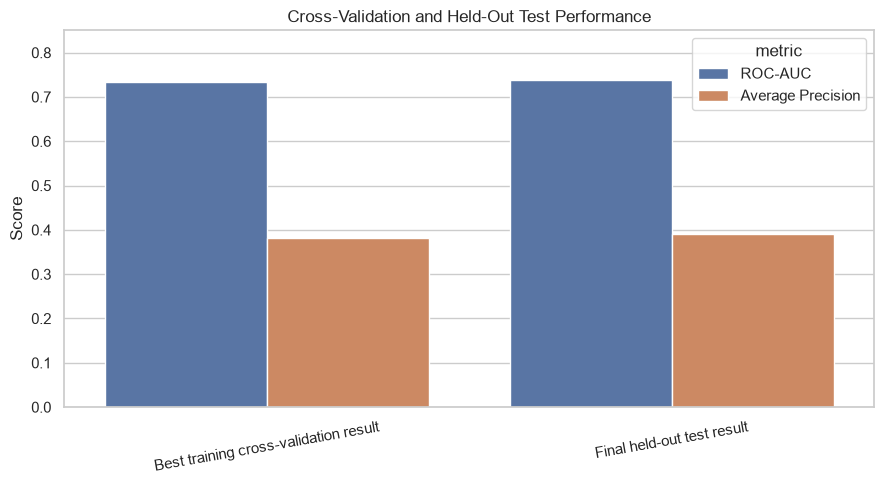

In [60]:
probability_metric_plot = (
    cv_test_comparison
    .melt(
        id_vars="evaluation_stage",
        var_name="metric",
        value_name="score",
    )
)

probability_metric_plot["metric"] = (
    probability_metric_plot["metric"]
    .map(
        {
            "roc_auc": "ROC-AUC",
            "average_precision": (
                "Average Precision"
            ),
        }
    )
)

figure, axis = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=probability_metric_plot,
    x="evaluation_stage",
    y="score",
    hue="metric",
    ax=axis,
)

axis.set_title(
    "Cross-Validation and Held-Out Test Performance"
)
axis.set_xlabel("")
axis.set_ylabel("Score")
axis.set_ylim(0, 0.85)
axis.tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()

### Threshold-Independent Performance

The final model achieved a held-out ROC-AUC of approximately 0.74 and an Average Precision substantially above the positive-class prevalence of approximately 11.7%.

Average Precision is particularly important here because the target is imbalanced.

The result indicates that the model ranks likely subscribers more effectively than random targeting, even without using current-campaign information such as call duration.

In [61]:
final_threshold_metrics = reports[
    "final_threshold_metrics"
].copy()

threshold_metric_columns = [
    "threshold_name",
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "negative_predictive_value",
    "f1",
    "f2",
    "lift_over_baseline",
    "predicted_positive_count",
    "predicted_positive_percentage",
    "true_positives",
    "false_positives",
    "false_negatives",
    "true_negatives",
]

display(
    final_threshold_metrics[
        threshold_metric_columns
    ]
)

,threshold_name,threshold,accuracy,balanced_accuracy,precision,recall,specificity,negative_predictive_value,f1,f2,lift_over_baseline,predicted_positive_count,predicted_positive_percentage,true_positives,false_positives,false_negatives,true_negatives
0,selected_training_oof_f1,0.5951,0.8597,0.6606,0.4004,0.4008,0.9205,0.9206,0.4006,0.4007,3.4221,1059,11.7107,424,635,634,7350
1,default_0_50,0.5000,0.7937,0.6806,0.2913,0.5331,0.8282,0.9305,0.3768,0.4572,2.4900,1936,21.4088,564,1372,494,6613


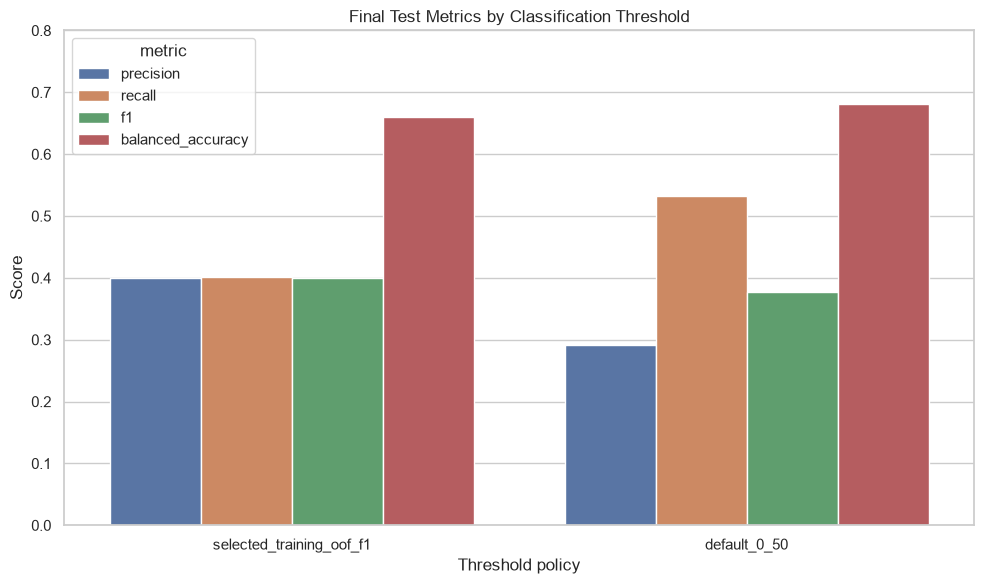

In [62]:
final_threshold_plot_data = (
    final_threshold_metrics[
        [
            "threshold_name",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
        ]
    ]
    .melt(
        id_vars="threshold_name",
        var_name="metric",
        value_name="score",
    )
)

figure, axis = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=final_threshold_plot_data,
    x="threshold_name",
    y="score",
    hue="metric",
    ax=axis,
)

axis.set_title(
    "Final Test Metrics by Classification Threshold"
)
axis.set_xlabel("Threshold policy")
axis.set_ylabel("Score")
axis.set_ylim(0, 0.80)

plt.tight_layout()
plt.show()

### Threshold Interpretation

The training-selected threshold is more conservative than the default threshold of 0.50.

It produces:

- Higher precision.
- A more balanced relationship between precision and recall.
- A higher F1-score.
- Fewer clients classified as likely subscribers.

The default threshold captures more actual subscribers, but it also generates more false-positive campaign contacts.

The appropriate production threshold may eventually depend on the monetary cost of contacting a client and the expected value of a successful subscription.

In [63]:
confusion_matrices = reports[
    "confusion_matrices"
].copy()

display(confusion_matrices)

,threshold_name,threshold,true_negatives,false_positives,false_negatives,true_positives
0,selected_training_oof_f1,0.5951,7350,635,634,424
1,default_0_50,0.5000,6613,1372,494,564


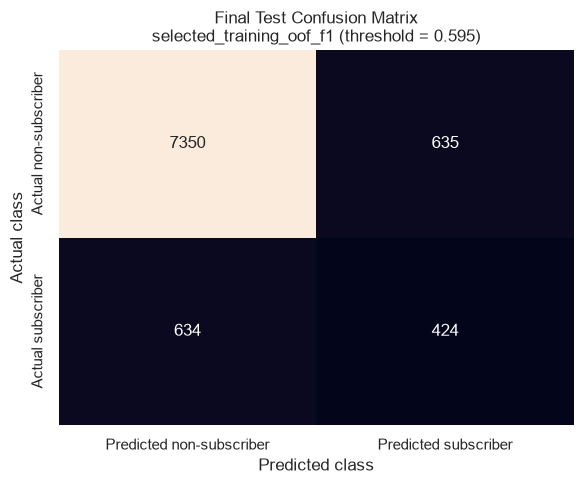

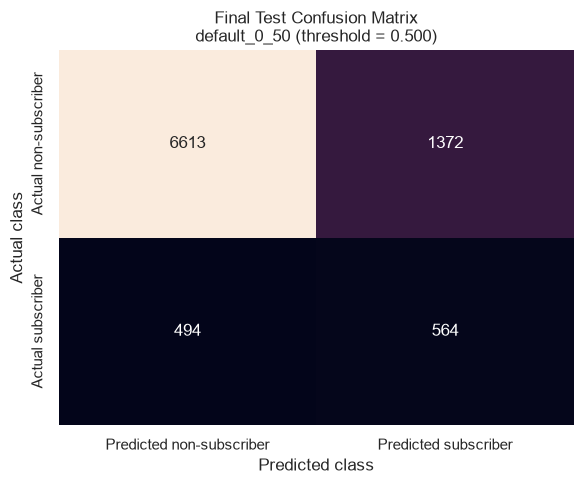

In [64]:
for _, result in confusion_matrices.iterrows():
    confusion_matrix_values = np.array(
        [
            [
                int(result["true_negatives"]),
                int(result["false_positives"]),
            ],
            [
                int(result["false_negatives"]),
                int(result["true_positives"]),
            ],
        ]
    )

    figure, axis = plt.subplots(figsize=(6, 5))

    sns.heatmap(
        confusion_matrix_values,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=[
            "Predicted non-subscriber",
            "Predicted subscriber",
        ],
        yticklabels=[
            "Actual non-subscriber",
            "Actual subscriber",
        ],
        ax=axis,
    )

    axis.set_title(
        "Final Test Confusion Matrix\n"
        f"{result['threshold_name']} "
        f"(threshold = {result['threshold']:.3f})"
    )

    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Actual class")

    plt.tight_layout()
    plt.show()

## 11. Receiver Operating Characteristic Curve

The ROC curve evaluates ranking performance across all possible classification thresholds.

The diagonal reference line represents random ranking.

ROC-AUC is threshold-independent, but it should be interpreted together with Average Precision because the target is imbalanced.

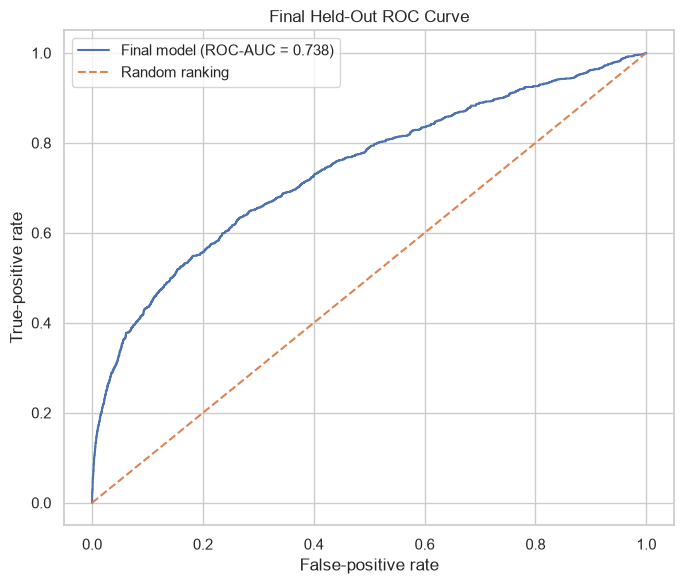

In [65]:
roc_curve_data = reports[
    "roc_curve"
].copy()

final_roc_auc = float(
    final_probability_metrics.loc[
        0,
        "roc_auc",
    ]
)

figure, axis = plt.subplots(figsize=(7, 6))

axis.plot(
    roc_curve_data["false_positive_rate"],
    roc_curve_data["true_positive_rate"],
    label=(
        f"Final model "
        f"(ROC-AUC = {final_roc_auc:.3f})"
    ),
)

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random ranking",
)

axis.set_title("Final Held-Out ROC Curve")
axis.set_xlabel("False-positive rate")
axis.set_ylabel("True-positive rate")
axis.legend()

plt.tight_layout()
plt.show()

## 12. Precision–Recall Curve

The Precision–Recall curve focuses on performance for the minority subscriber class.

The horizontal baseline represents the subscription prevalence in the held-out test set.

A useful model should produce a curve and Average Precision above this baseline.

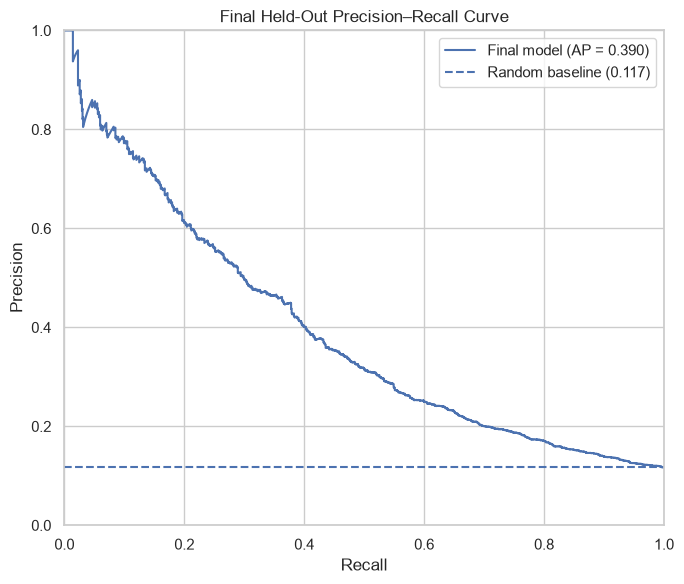

In [66]:
precision_recall_curve_data = reports[
    "precision_recall_curve"
].copy()

test_prevalence = float(
    final_probability_metrics.loc[
        0,
        "positive_class_prevalence",
    ]
)

final_average_precision = float(
    final_probability_metrics.loc[
        0,
        "average_precision",
    ]
)

figure, axis = plt.subplots(figsize=(7, 6))

axis.plot(
    precision_recall_curve_data["recall"],
    precision_recall_curve_data["precision"],
    label=(
        "Final model "
        f"(AP = {final_average_precision:.3f})"
    ),
)

axis.axhline(
    test_prevalence,
    linestyle="--",
    label=(
        "Random baseline "
        f"({test_prevalence:.3f})"
    ),
)

axis.set_title(
    "Final Held-Out Precision–Recall Curve"
)
axis.set_xlabel("Recall")
axis.set_ylabel("Precision")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.legend()

plt.tight_layout()
plt.show()

## 13. Campaign Targeting Lift

A probability-ranking model may be useful even when a single binary threshold is not the final business policy.

The bank can rank clients by predicted subscription probability and contact only the highest-ranked fraction.

The following analysis measures:

- Number of targeted clients.
- Number and percentage of subscribers captured.
- Subscription rate among targeted clients.
- Lift compared with random targeting.

In [67]:
targeting_lift = reports[
    "targeting_lift"
].copy()

display(targeting_lift)

,targeting_fraction,targeting_percentage,targeted_clients,subscribers_captured,subscriber_capture_rate,subscriber_capture_percentage,targeting_precision,targeting_precision_percentage,baseline_subscription_rate,lift_over_random_targeting,expected_subscribers_under_random_targeting,additional_subscribers_vs_random_expectation
0,0.0500,5.0000,453,256,0.2420,24.1966,0.5651,56.5121,0.1170,4.8302,52.9994,203.0006
1,0.1000,10.0000,905,400,0.3781,37.8072,0.4420,44.1989,0.1170,3.7778,105.8819,294.1181
2,0.2000,20.0000,1809,551,0.5208,52.0794,0.3046,30.4588,0.1170,2.6034,211.6468,339.3532
3,0.3000,30.0000,2713,655,0.6191,61.9093,0.2414,24.1430,0.1170,2.0636,317.4117,337.5883
4,0.5000,50.0000,4522,813,0.7684,76.8431,0.1798,17.9788,0.1170,1.5367,529.0585,283.9415
5,1.0000,100.0000,9043,1058,1.0000,100.0000,0.1170,11.6997,0.1170,1.0000,"1,058.0000",0.0000


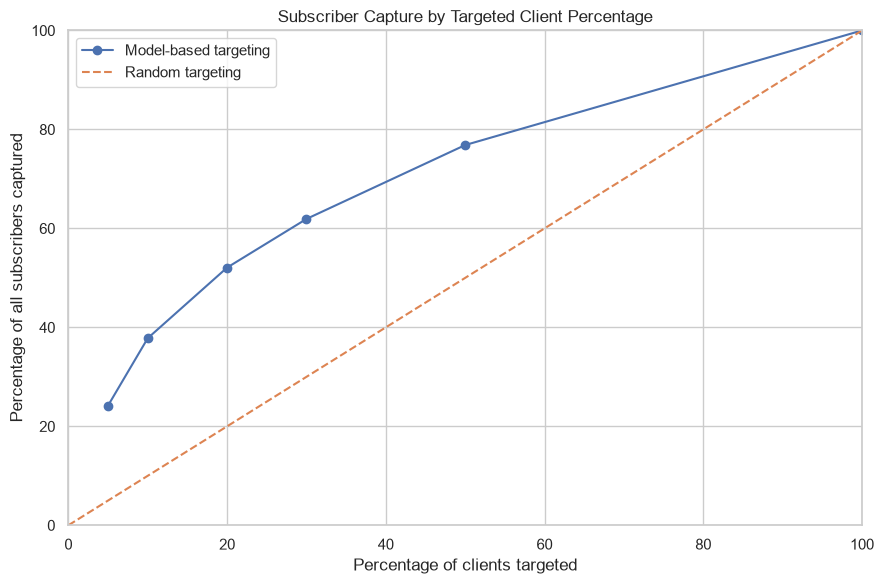

In [68]:
figure, axis = plt.subplots(figsize=(9, 6))

axis.plot(
    targeting_lift["targeting_percentage"],
    targeting_lift[
        "subscriber_capture_percentage"
    ],
    marker="o",
    label="Model-based targeting",
)

axis.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random targeting",
)

axis.set_title(
    "Subscriber Capture by Targeted Client Percentage"
)
axis.set_xlabel("Percentage of clients targeted")
axis.set_ylabel(
    "Percentage of all subscribers captured"
)
axis.set_xlim(0, 100)
axis.set_ylim(0, 100)
axis.legend()

plt.tight_layout()
plt.show()

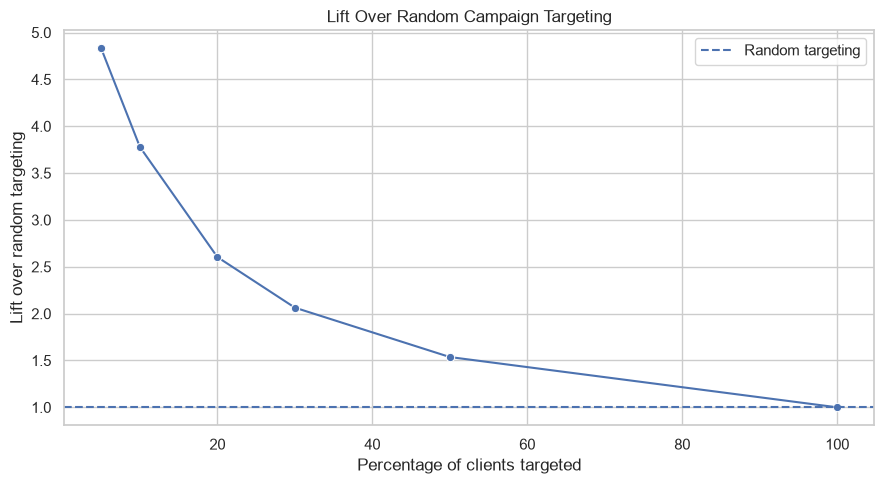

In [69]:
figure, axis = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=targeting_lift,
    x="targeting_percentage",
    y="lift_over_random_targeting",
    marker="o",
    ax=axis,
)

axis.axhline(
    1,
    linestyle="--",
    label="Random targeting",
)

axis.set_title(
    "Lift Over Random Campaign Targeting"
)
axis.set_xlabel("Percentage of clients targeted")
axis.set_ylabel("Lift over random targeting")
axis.legend()

plt.tight_layout()
plt.show()

In [70]:
operational_targeting_scenarios = (
    targeting_lift.loc[
        targeting_lift[
            "targeting_percentage"
        ].isin([5.0, 10.0, 20.0, 30.0])
    ]
    [
        [
            "targeting_percentage",
            "targeted_clients",
            "subscribers_captured",
            "subscriber_capture_percentage",
            "targeting_precision_percentage",
            "lift_over_random_targeting",
            "additional_subscribers_vs_random_expectation",
        ]
    ]
    .reset_index(drop=True)
)

display(operational_targeting_scenarios)

,targeting_percentage,targeted_clients,subscribers_captured,subscriber_capture_percentage,targeting_precision_percentage,lift_over_random_targeting,additional_subscribers_vs_random_expectation
0,5.0000,453,256,24.1966,56.5121,4.8302,203.0006
1,10.0000,905,400,37.8072,44.1989,3.7778,294.1181
2,20.0000,1809,551,52.0794,30.4588,2.6034,339.3532
3,30.0000,2713,655,61.9093,24.1430,2.0636,337.5883


### Business Interpretation of Ranking

The model can help the bank reduce campaign volume by prioritizing higher-probability customers.

The appropriate targeting percentage should be chosen using:

- Available campaign capacity.
- Cost per contact.
- Expected value of a successful subscription.
- Customer-contact fatigue.
- Required subscriber coverage.
- Regulatory and fairness constraints.

The lift analysis describes ranking value. It does not prove that contacting a high-ranked client causes subscription.

## 14. Held-Out Permutation Importance

Permutation importance measures how much held-out Average Precision decreases when one feature is randomly shuffled.

A larger decrease indicates that the model relied more strongly on that feature for test-set ranking performance.

Permutation importance:

- Describes predictive reliance.
- Does not establish causality.
- May distribute importance across correlated or overlapping features.

In [71]:
permutation_importance_data = reports[
    "permutation_importance"
].copy()

display(
    permutation_importance_data[
        [
            "importance_rank",
            "feature",
            "importance_mean",
            "importance_std",
        ]
    ]
)

,importance_rank,feature,importance_mean,importance_std
0,1,poutcome,0.1341,0.0052
1,2,housing,0.0475,0.0035
2,3,pdays_since_previous_contact,0.0304,0.0034
3,4,age,0.0273,0.0027
4,5,balance,0.0159,0.0044
5,6,previously_contacted,0.0103,0.0018
6,7,loan,0.0101,0.0022
7,8,marital,0.0071,0.0017
8,9,previous,0.0069,0.0014
9,10,education,0.0058,0.0014


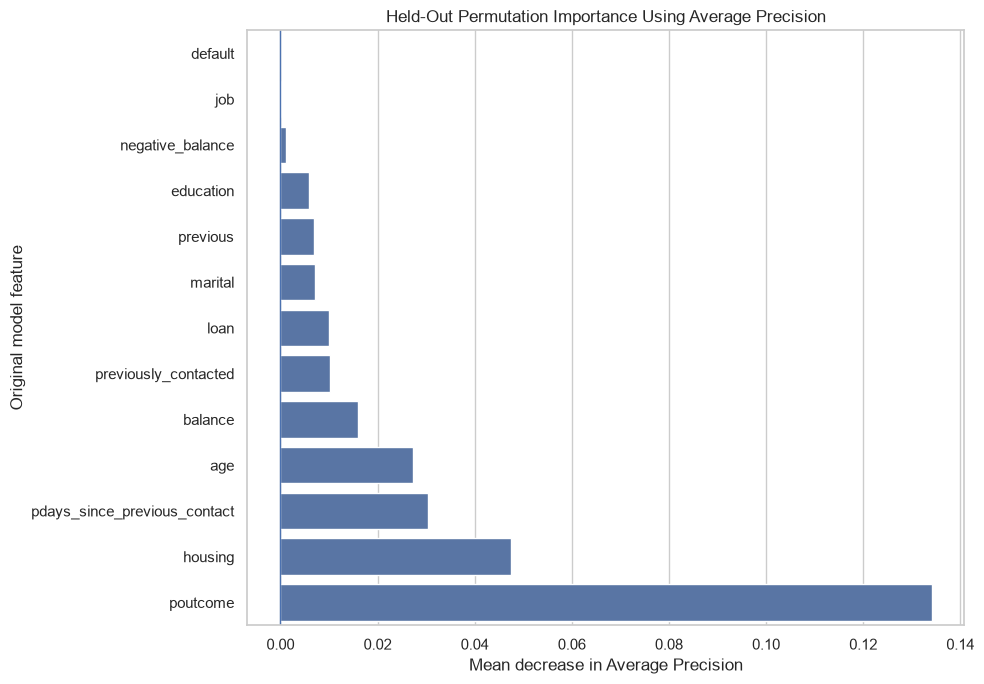

In [72]:
importance_plot_data = (
    permutation_importance_data
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

figure, axis = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=importance_plot_data,
    x="importance_mean",
    y="feature",
    ax=axis,
)

axis.axvline(
    0,
    linewidth=1,
)

axis.set_title(
    "Held-Out Permutation Importance "
    "Using Average Precision"
)
axis.set_xlabel(
    "Mean decrease in Average Precision"
)
axis.set_ylabel("Original model feature")

plt.tight_layout()
plt.show()

### Model-Interpretation Result

Previous campaign outcome was the most important feature in the held-out permutation analysis.

Other important predictors included:

- Housing-loan status.
- Time since previous contact.
- Age.
- Account balance.
- Previous-contact history.

These results indicate which variables contributed most to predictive performance, not which variables caused subscription.

In [73]:
model_metadata = json_reports[
    "model_metadata"
]

metadata_summary = pd.DataFrame(
    [
        {
            "model_name": (
                model_metadata["model_name"]
            ),
            "model_type": (
                model_metadata["model_type"]
            ),
            "training_rows": (
                model_metadata["training_rows"]
            ),
            "test_rows": (
                model_metadata["test_rows"]
            ),
            "selected_threshold": (
                model_metadata[
                    "selected_threshold"
                ]
            ),
            "model_file": (
                model_metadata["model_file"]
            ),
            "created_at_utc": (
                model_metadata["created_at_utc"]
            ),
            "test_used_for_selection": (
                model_metadata[
                    "test_set_used_for_model_selection"
                ]
            ),
            "test_used_for_final_reporting": (
                model_metadata[
                    "test_set_used_for_final_reporting"
                ]
            ),
        }
    ]
)

display(metadata_summary)

,model_name,model_type,training_rows,test_rows,selected_threshold,model_file,created_at_utc,test_used_for_selection,test_used_for_final_reporting
0,Bank Marketing Pre-Campaign Balanced Random Fo...,RandomForestClassifier,36168,9043,0.5951,models\bank_marketing_pre_campaign_random_fore...,2026-08-01T17:09:21.978469+00:00,False,True


In [74]:
local_model_path = (
    PROJECT_ROOT
    / model_metadata["model_file"]
)

artifact_status = pd.DataFrame(
    [
        {
            "local_model_path": str(
                local_model_path
            ),
            "exists_locally": (
                local_model_path.exists()
            ),
            "tracked_in_repository": False,
            "rebuild_command": (
                "python src\\evaluate.py"
            ),
        }
    ]
)

display(artifact_status)

,local_model_path,exists_locally,tracked_in_repository,rebuild_command
0,C:\Users\omary\Documents\VS Code\bank-marketin...,True,False,python src\evaluate.py


### Model Persistence

The fitted pipeline contains:

- Numerical preprocessing.
- Categorical preprocessing.
- One-hot encoding.
- The tuned Random Forest classifier.
- The selected classification threshold.
- The prediction-time feature contract.

The binary model artifact is generated locally and excluded from Git because serialized models are environment-dependent and can be rebuilt from the versioned source code and reports.

In [75]:
selected_test_result = (
    final_threshold_metrics.loc[
        final_threshold_metrics[
            "threshold_name"
        ] == "selected_training_oof_f1"
    ]
    .iloc[0]
)

top_feature_result = (
    permutation_importance_data
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .iloc[0]
)

top_ten_percent_result = (
    targeting_lift.loc[
        np.isclose(
            targeting_lift[
                "targeting_percentage"
            ],
            10.0,
        )
    ]
    .iloc[0]
)

display(
    Markdown(
        f"""
## Final Model Executive Summary

- **Model:** Tuned class-balanced Random Forest.
- **Prediction point:** Before current-campaign contacts begin.
- **Test records:** {int(final_probability_result["test_records"]):,}.
- **Test subscribers:** {int(final_probability_result["test_subscribers"]):,}.
- **ROC-AUC:** {final_probability_result["roc_auc"]:.3f}.
- **Average Precision:** {final_probability_result["average_precision"]:.3f}.
- **Selected threshold:** {selected_test_result["threshold"]:.3f}.
- **Precision at the selected threshold:** {selected_test_result["precision"]:.1%}.
- **Recall at the selected threshold:** {selected_test_result["recall"]:.1%}.
- **F1-score at the selected threshold:** {selected_test_result["f1"]:.3f}.
- **Lift among selected positive predictions:** {selected_test_result["lift_over_baseline"]:.2f}× the overall subscription rate.
- **Top 10% targeting:** captures {top_ten_percent_result["subscriber_capture_percentage"]:.1f}% of test subscribers with {top_ten_percent_result["lift_over_random_targeting"]:.2f}× lift over random targeting.
- **Most important held-out permutation feature:** `{top_feature_result["feature"]}`.

The model provides useful ranking and prioritization value without using call duration or other current-campaign features.
"""
    )
)


## Final Model Executive Summary

- **Model:** Tuned class-balanced Random Forest.
- **Prediction point:** Before current-campaign contacts begin.
- **Test records:** 9,043.
- **Test subscribers:** 1,058.
- **ROC-AUC:** 0.738.
- **Average Precision:** 0.390.
- **Selected threshold:** 0.595.
- **Precision at the selected threshold:** 40.0%.
- **Recall at the selected threshold:** 40.1%.
- **F1-score at the selected threshold:** 0.401.
- **Lift among selected positive predictions:** 3.42× the overall subscription rate.
- **Top 10% targeting:** captures 37.8% of test subscribers with 3.78× lift over random targeting.
- **Most important held-out permutation feature:** `poutcome`.

The model provides useful ranking and prioritization value without using call duration or other current-campaign features.


## 17. Limitations and Responsible Use

### Data limitations

- The dataset represents historical campaign records rather than a randomized experiment.
- The model may learn historical targeting and operational patterns.
- Performance may change when customer behavior, campaign design, or economic conditions change.
- Future deployment requires monitoring for data drift and performance drift.

### Prediction limitations

- The model prioritizes customers; it does not estimate the causal effect of contacting them.
- Predicted probabilities should be monitored and recalibrated when necessary.
- A final production threshold should incorporate campaign costs and subscription value.
- The model should not be used for credit approval or customer exclusion.

### Fairness considerations

- Age and marital status may raise fairness or policy concerns.
- Segment-level performance should be audited before production use.
- A reduced-feature sensitivity model should be considered before operational deployment.
- Human and regulatory review remain necessary.

### Artifact limitations

The serialized model is environment-dependent and is not committed to Git. It must be rebuilt using the documented Python environment and training workflow.

## 18. Final Machine-Learning Notebook Validation

The following checks verify that the notebook reflects the frozen modeling reports and that no final-test results are used to redefine the model or threshold.

In [76]:
assert len(final_probability_metrics) == 1

assert int(
    final_probability_metrics.loc[
        0,
        "test_records",
    ]
) == 9_043

assert int(
    final_probability_metrics.loc[
        0,
        "test_subscribers",
    ]
) == 1_058

assert (
    final_probability_metrics.loc[
        0,
        "roc_auc",
    ]
    > 0.5
)

assert (
    final_probability_metrics.loc[
        0,
        "average_precision",
    ]
    > final_probability_metrics.loc[
        0,
        "positive_class_prevalence",
    ]
)

assert set(
    final_threshold_metrics[
        "threshold_name"
    ]
) == {
    "selected_training_oof_f1",
    "default_0_50",
}

selected_threshold_from_report = float(
    final_threshold_metrics.loc[
        final_threshold_metrics[
            "threshold_name"
        ] == "selected_training_oof_f1",
        "threshold",
    ].iloc[0]
)

selected_threshold_from_json = float(
    selected_threshold_metadata[
        "threshold"
    ]
)

assert np.isclose(
    selected_threshold_from_report,
    selected_threshold_from_json,
)

selected_f1 = float(
    final_threshold_metrics.loc[
        final_threshold_metrics[
            "threshold_name"
        ] == "selected_training_oof_f1",
        "f1",
    ].iloc[0]
)

default_f1 = float(
    final_threshold_metrics.loc[
        final_threshold_metrics[
            "threshold_name"
        ] == "default_0_50",
        "f1",
    ].iloc[0]
)

assert selected_f1 >= default_f1

confusion_totals = (
    confusion_matrices[
        [
            "true_negatives",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
    .sum(axis=1)
)

assert (
    confusion_totals == 9_043
).all()

assert not roc_curve_data.empty
assert not precision_recall_curve_data.empty

assert len(permutation_importance_data) == 13

full_targeting_result = (
    targeting_lift.loc[
        np.isclose(
            targeting_lift[
                "targeting_percentage"
            ],
            100.0,
        )
    ]
    .iloc[0]
)

assert int(
    full_targeting_result[
        "targeted_clients"
    ]
) == 9_043

assert int(
    full_targeting_result[
        "subscribers_captured"
    ]
) == 1_058

assert np.isclose(
    full_targeting_result[
        "lift_over_random_targeting"
    ],
    1.0,
)

assert (
    model_metadata[
        "test_set_used_for_model_selection"
    ]
    is False
)

assert (
    model_metadata[
        "test_set_used_for_final_reporting"
    ]
    is True
)

assert np.isclose(
    float(
        model_metadata[
            "selected_threshold"
        ]
    ),
    selected_threshold_from_json,
)

print(
    "All machine-learning notebook analyses "
    "and final validation checks passed successfully."
)

All machine-learning notebook analyses and final validation checks passed successfully.


## 19. Machine-Learning Summary

The machine-learning workflow developed and evaluated a reproducible pre-campaign client-prioritization model.

Main methodological decisions:

- The prediction point was defined before current-campaign contacts begin.
- Current-campaign features were excluded to prevent temporal leakage.
- The test set remained isolated during model selection, tuning, and threshold selection.
- All preprocessing was included inside scikit-learn pipelines.
- Candidate models were evaluated using stratified cross-validation.
- Average Precision was used as the primary selection metric because the target is imbalanced.
- A class-balanced Random Forest achieved the strongest candidate performance.
- Hyperparameters were selected using training data only.
- The operating threshold was selected from training out-of-fold probabilities.
- Final performance was evaluated once on the held-out test set.
- Business lift was evaluated through ranked targeting scenarios.
- Permutation importance was used for held-out model interpretation.
- The model artifact and reproducibility metadata were saved locally.

The final model provides useful campaign-ranking value while respecting the real prediction-time information boundary.